# 7. SHAP — interpretowalność modelu RF

**Autor:** Marta Gałuszka · **2026-08** · Zadanie 14 (kurs)

**SHAP** wyjaśnia, które cechy **podnoszą lub obniżają** prognozę kWh/h (Random Forest × 16 cech).

Pełny raport komentarzy: [`reports/shap_interpretation.md`](../reports/shap_interpretation.md)

Generator wykresów: [`scripts/analysis/plot_shap_interpretability.py`](../scripts/analysis/plot_shap_interpretability.py)


In [1]:
from pathlib import Path
import os, sys
import importlib.util
import pandas as pd
from IPython.display import Image, display, Markdown

def _find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, here.parent):
        if (cand / 'src').is_dir():
            return cand
    return here.parent

ROOT = _find_root()
os.chdir(ROOT)
FIG = ROOT / 'reports' / 'figures'
DATA = ROOT / 'data' / 'processed'

spec = importlib.util.spec_from_file_location(
    'shap_plot', ROOT / 'scripts/analysis/plot_shap_interpretability.py'
)
shap_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(shap_mod)
PLOT_COMMENTS = shap_mod.PLOT_COMMENTS

def show_plot(key: str, png: str) -> None:
    c = PLOT_COMMENTS[key]
    display(Markdown(f"## {c['title']}\n\n*{c['caption']}*\n\n{c['body']}"))
    display(Image(filename=str(FIG / png)))

print('ROOT:', ROOT)


FoxESS-Cloud Open API version 2.9.15
ROOT: /path/to/smart-energy-model


/path/to/smart-energy-model/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import subprocess
subprocess.run([
    sys.executable,
    str(ROOT / 'scripts/analysis/plot_shap_interpretability.py'),
    '--max-samples', '300',
], check=True)


/path/to/smart-energy-model/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


FoxESS-Cloud Open API version 2.9.15
SHAP — Random Forest 16 cech (produkcja)
✓ Target godzinowy = PVEnergyTotal (Δ licznika, jak w app): 356 dni, 3816 godzin
✓ Dodano flagi śniegu z modelu topnienia (dni ze śniegiem: 35 / 356)
✓ Dodano flagę mgły (dni z mgłą: 142 / 356)
📊 Statystyki godzin produkcji:
   Najwcześniejsza: 5:00
   Najpóźniejsza: 19:00
   Średni wschód słońca: 5.82
   Średni zachód słońca: 18.92
Obliczanie SHAP dla 300 wierszy testowych (RF, 16 cech)...
  ✓ /path/to/smart-energy-model/reports/figures/shap_summary_beeswarm.png
  ✓ /path/to/smart-energy-model/reports/figures/shap_summary_bar.png
  ✓ /path/to/smart-energy-model/reports/figures/shap_dependence_radiation_wm2.png
  ✓ /path/to/smart-energy-model/reports/figures/shap_dependence_cloud_cover_pct.png
  ✓ /path/to/smart-energy-model/reports/figures/shap_waterfall_peak_hour.png (peak PV=5.00 kWh/h)
  ✓ /path/to/smart-energy-model/reports/figures/shap_force_peak_hour.html
  ✓ /path/to/smart-energy-model/data/processed/

CompletedProcess(args=['/path/to/smart-energy-model/venv/bin/python', '/path/to/smart-energy-model/scripts/analysis/plot_shap_interpretability.py', '--max-samples', '300'], returncode=0)

## Ranking cech — mean |SHAP|

Tabela sortuje cechy po **mean |SHAP|** — im wyżej, tym częściej i silniej dana zmienna przesuwa prognozę RF. Na szczycie listy są **zachmurzenie** i **geometria dnia** (`hours_until_sunset`, `sun_position`), a nie surowa **godzina kalendarzowa** (`hour` jest dopiero ~9. pozycji). To uzasadnia ablację 19→16 cech: model opiera się na fizyce PV i NWP, nie na sztywnym „o 12:00 zawsze X kWh".

In [3]:
rank = pd.read_csv(DATA / 'shap_feature_ranking.csv')
display(rank)


,feature,label,mean_abs_shap
0,cloud_cover_pct,Zachmurzenie [%],0.565610
1,hours_until_sunset,Do zachodu [h],0.518451
2,sun_position,Pozycja słońca,0.267843
3,radiation_wm2,Radiacja [W/m²],0.260587
4,sunrise_hour,Wschód [h],0.032087
5,hours_since_sunrise,Od wschodu [h],0.029400
6,wind_speed_ms,Wiatr [m/s],0.019314
7,humidity_pct,Wilgotność [%],0.016534
8,hour,Godzina,0.015371
9,temp_c,Temperatura [°C],0.012456


## Summary bar — średni wpływ cech

*Długość słupka = mean |SHAP| · RF produkcyjny · holdout 20% dni · tylko is_daylight=1.*

Wykres słupkowy to **zagregowany** obraz ważności: ile średnio każda cecha „rusza" prognozą we wszystkich godzinach testowych. **Zachmurzenie** ma największy udział — zgodnie z intuicją (pochmurny dzień → mniej kWh). **Do zachodu** i **pozycja słońca** kodują kształt profilu dobowego (rano vs południe vs wieczór). **Radiacja** jest 4. na liście — ważna, ale częściowo skorelowana z chmurami i kątem słońca.

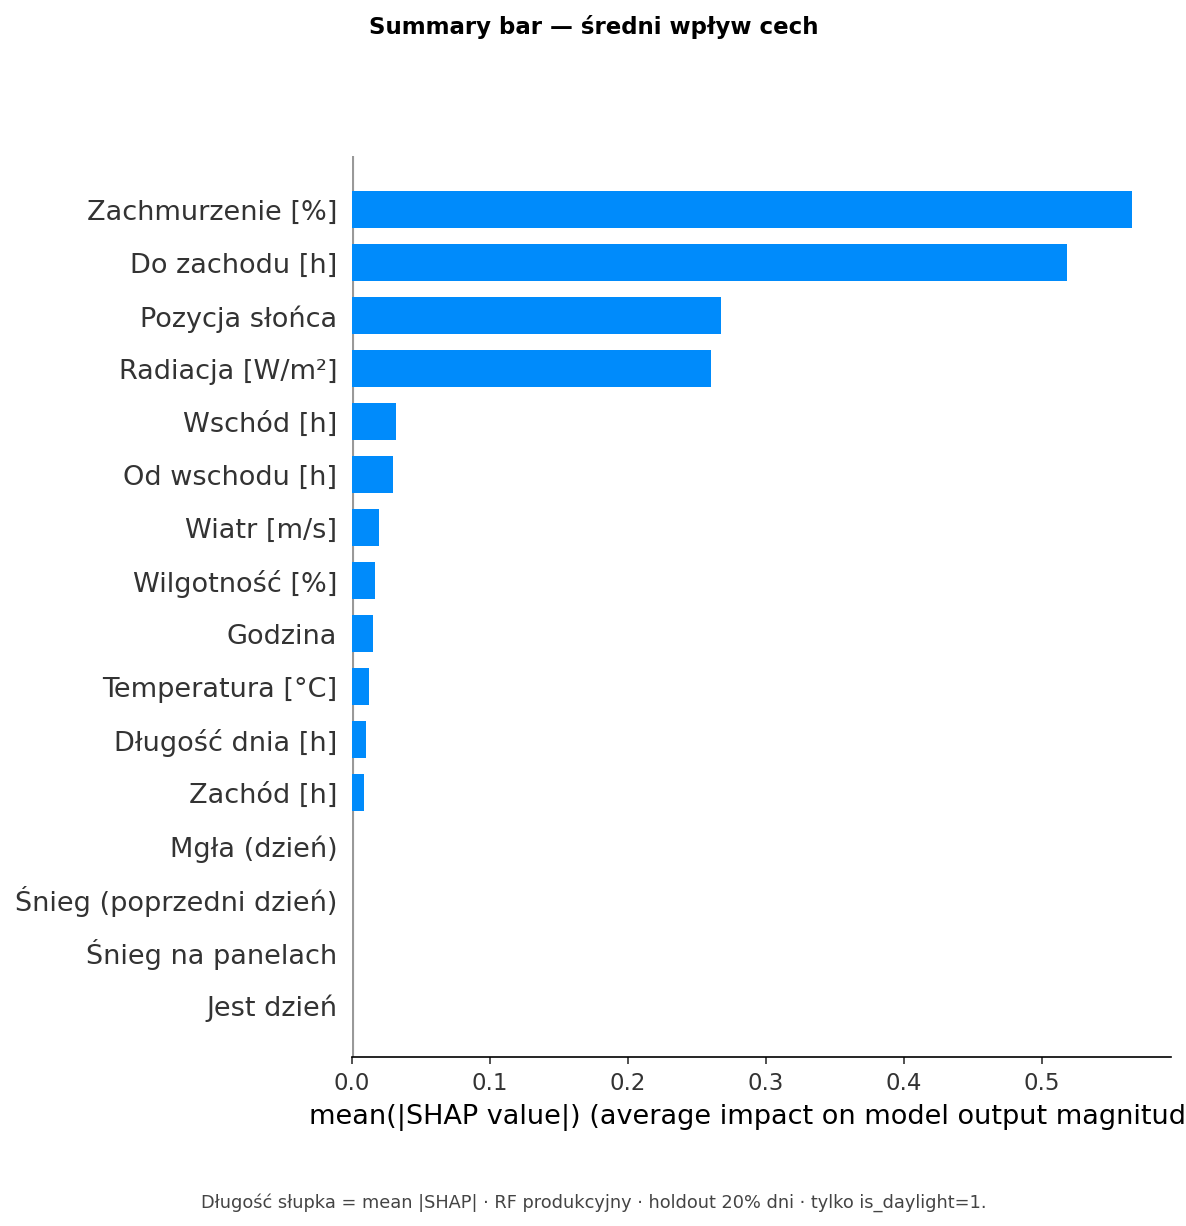

## Summary beeswarm — kierunek i rozkład wpływu

*Oś X: SHAP [kWh/h] · kolor: wartość cechy · każdy punkt = jedna godzina testowa.*

Każda kropka to **jedna godzina** ze zbioru testowego. Pozycja w poziomie: **SHAP > 0** podnosi prognozę względem średniej modelu, **SHAP < 0** ją obniża. Kolor pokazuje wartość cechy (np. czerwone = wysokie zachmurzenie). Widać, że przy **dużym zachmurzeniu** punkty idą w lewo (ujemny wpływ), a przy **wysokiej radiacji** — w prawo. Rozproszenie w pionie przy tej samej cechie oznacza **interakcje** z innymi zmiennymi (RF jest nieliniowy).

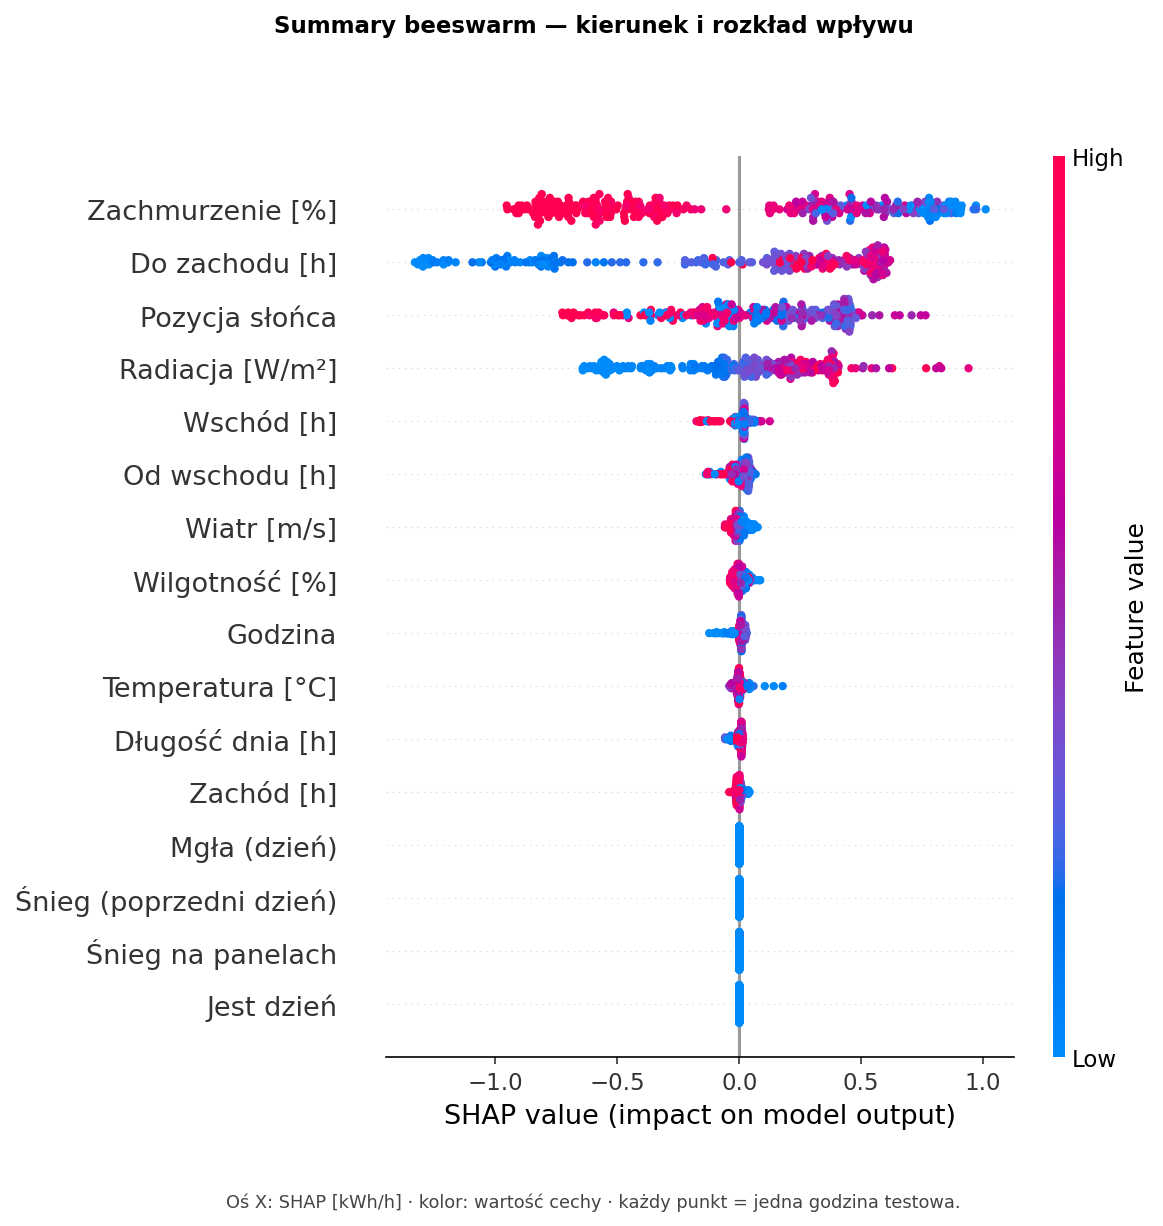

## Dependence — radiacja [W/m²]

*Oś Y: wpływ radiacji na prognozę · oś X: radiacja · kolor: interakcja z inną cechą.*

Pokazuje, jak ** sama wartość radiacji** przekłada się na korektę prognozy. Przy niskiej radiacji (<200 W/m²) wpływ jest bliski zera — model „wie", że i tak mało wyprodukujesz. Powyżej ~400 W/m² SHAP rośnie dodatnio: silne słońce podbija kWh/h. Kolor punktów sugeruje, że ten sam poziom radiacji może działać inaczej w zależności np. od chmur lub pory dnia.

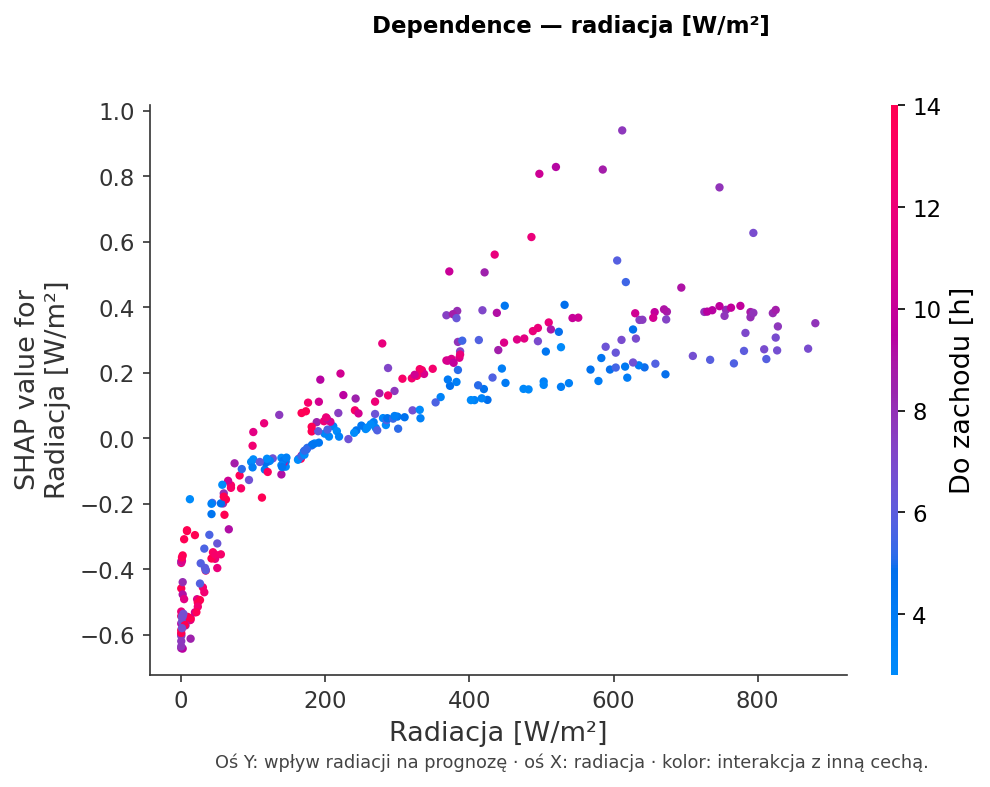

## Dependence — zachmurzenie [%]

*Przy wysokim cloud_cover SHAP schodzi w minus — mniej energii niż przy czystym niebie.*

Najczytelniejsza monotonia: **im więcej chmur, tym niższa prognoza**. To potwierdza, że model nie ignoruje pogody na rzecz samego kalendarza — kluczowe dla dni burzowych (błąd operacyjny 21.07 w analizie błędów). Szeroki „garb" przy średnim zachmurzeniu to godziny, gdzie inne cechy (radiacja, pozycja słońca) modulują efekt chmur.

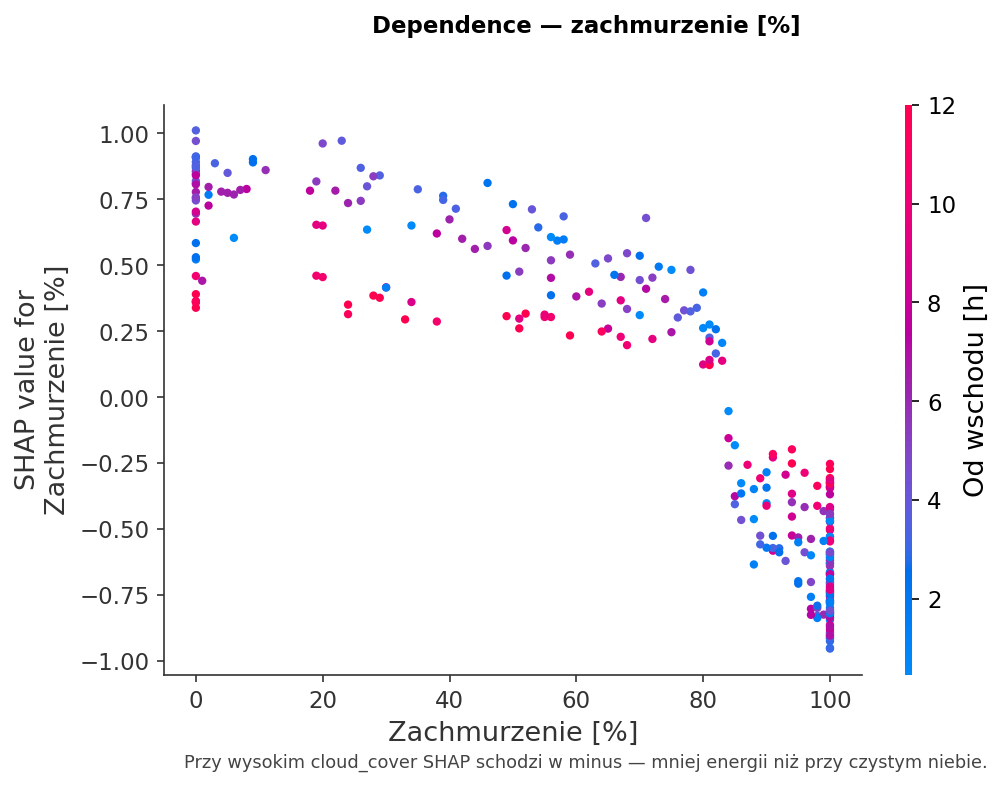

## Waterfall — skład prognozy w godzinie szczytu PV

*f(x) = E[f(X)] + Σ SHAP — przykład z najwyższą rzeczywistą PV w próbce testowej.*

Waterfall rozkłada **jedną konkretną prognozę** na sumę wpływów: start od **wartości bazowej** modelu (średnia), potem kolejne cechy dokładają lub odejmują kWh/h. Wybrano godzinę z **maksymalną rzeczywistą produkcją** w próbce — widać, które cechy „dociągnęły" prognozę w górę (słońce, radiacja) i co ją hamowało (chmury). Odpowiednik **force plot** w wersji statycznej pod slajd / PDF.

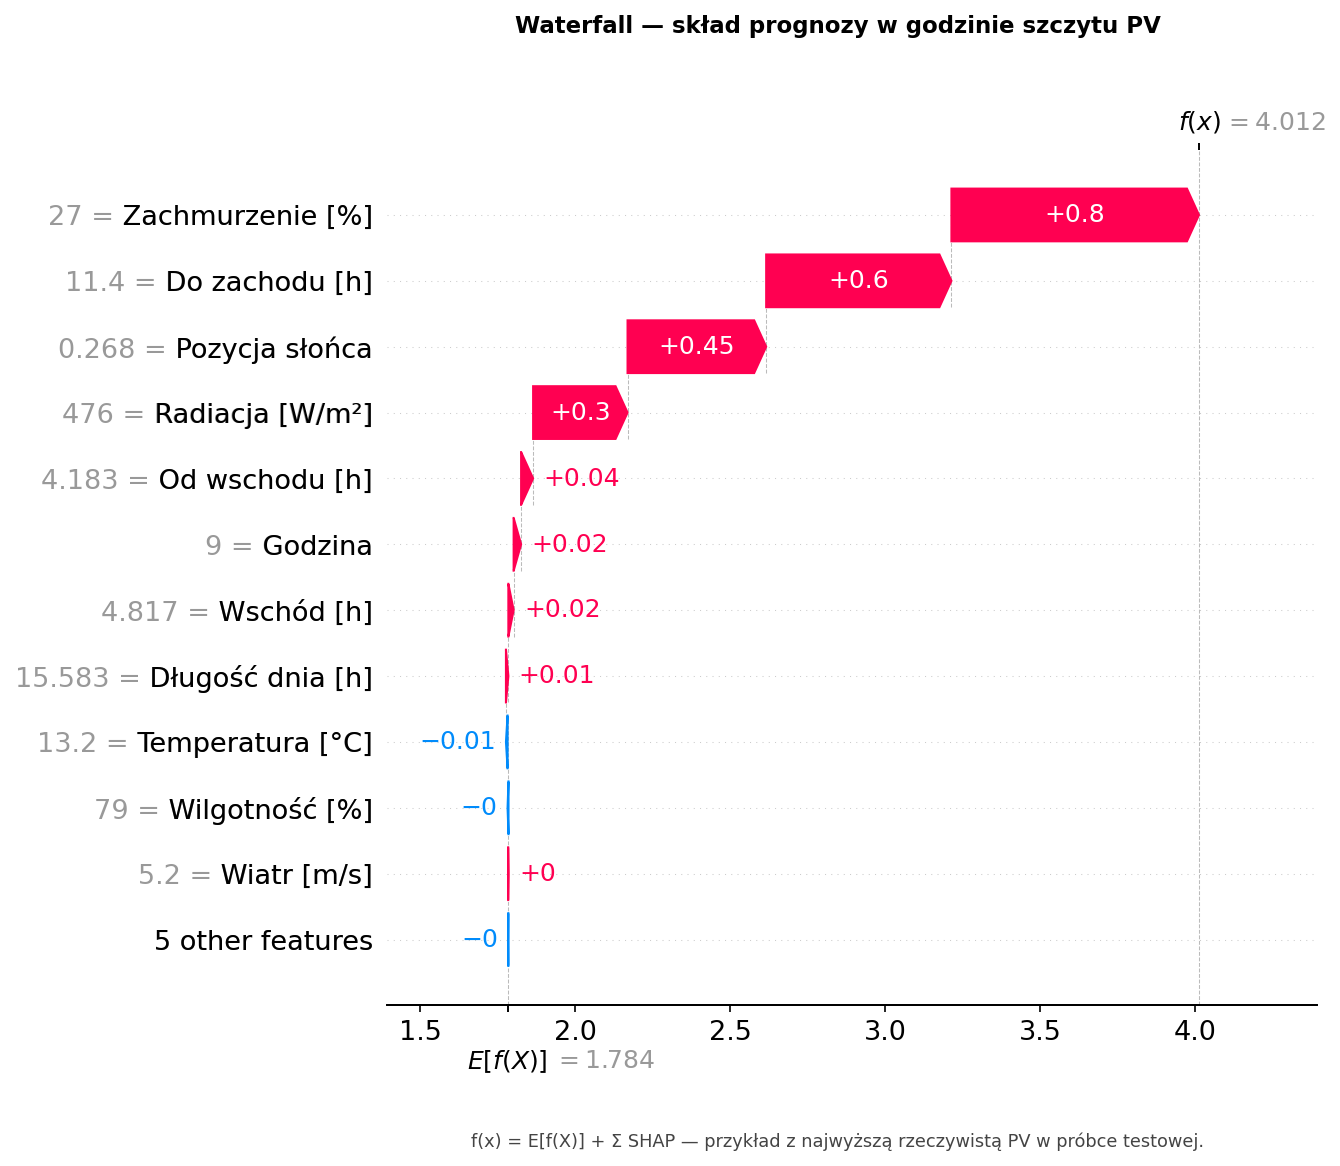

In [4]:
show_plot('bar', 'shap_summary_bar.png')
show_plot('beeswarm', 'shap_summary_beeswarm.png')
show_plot('dependence_radiation_wm2', 'shap_dependence_radiation_wm2.png')
show_plot('dependence_cloud_cover_pct', 'shap_dependence_cloud_cover_pct.png')
show_plot('waterfall', 'shap_waterfall_peak_hour.png')


## Force plot (HTML) — ten sam przykład interaktywnie

*Czerwone = podbija prognozę · niebieskie = obniża · otwórz plik HTML w przeglądarce.*

Interaktywny **force plot** dla tej samej godziny co waterfall. Przydatny na obronie live (przewijanie, zoom). Plik: `reports/figures/shap_force_peak_hour.html`.

In [5]:
display(Markdown(
    'Otwórz w przeglądarce: '
    '[`shap_force_peak_hour.html`](../reports/figures/shap_force_peak_hour.html)'
))


Otwórz w przeglądarce: [`shap_force_peak_hour.html`](../reports/figures/shap_force_peak_hour.html)

## Wnioski końcowe

- Model **nie opiera się na sztywnej godzinie** — ważniejsza jest **pogoda** i **geometria słońca w dniu**.
- **Zachmurzenie** i **pozycja w dobie** tłumaczą większość zmienności prognozy — spójne z analizą błędów burzowych.
- SHAP potwierdza sens wyboru **16 cech produkcyjnych** (ablacja vs kalendarz).

Powiązane: [`02_ML_predykcja_PV.ipynb`](02_ML_predykcja_PV.ipynb) · slajd 7 w [`03_prezentacja_dyplomowa.ipynb`](03_prezentacja_dyplomowa.ipynb)
